In [ ]:
# ============================================================
# CELL 1 — QAOA Full Local Simulation (Colab CPU)
# No IBM — measures pure QAOA algorithmic time only
# ============================================================
!pip install qiskit qiskit-algorithms qiskit-optimization matplotlib numpy -q

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
from scipy.sparse import SparseEfficiencyWarning
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

from qiskit.primitives import StatevectorSampler as LocalSampler
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

# ------------------------------------------------------------
# 1. System matrices
# ------------------------------------------------------------
def build_system_matrices(n, beta=0.8, delta=0.1, gamma=0.3, eta=0.9, alpha=0.5):
    A = np.zeros((2*n, 2*n))
    for i in range(n):
        A[i,   i]   = 1 - delta
        A[i,   n+i] = beta
        A[n+i, n+i] = 1 - gamma
    B = np.zeros((2*n, n))
    for i in range(n):
        B[n+i, i] = -eta
    F = np.zeros((2*n, n))
    for i in range(n):
        F[n+i, i] = alpha
    return A, B, F

n = 8
A, B, F = build_system_matrices(n)
Q = np.diag([2.0]*n + [3.0]*n)
R = np.diag([0.05]*n)

# ------------------------------------------------------------
# 2. QUBO builder (disturbance-aware — fixed)
# ------------------------------------------------------------
def build_qubo_local(x, Q, R, A, B, F, w_k):
    H = B.T @ Q @ B + R
    g = 2 * B.T @ Q @ (A @ x + F @ w_k)  # includes attack disturbance
    return H, g.flatten()

# ------------------------------------------------------------
# 3. QuadraticProgram builder
# ------------------------------------------------------------
def build_qp(H, g):
    num_vars = len(g)
    qp       = QuadraticProgram()
    for i in range(num_vars):
        qp.binary_var(f'x{i}')
    linear    = {f'x{i}': g[i] for i in range(num_vars)}
    quadratic = {}
    for i in range(num_vars):
        if abs(H[i, i]) > 1e-9:
            linear[f'x{i}'] = linear.get(f'x{i}', 0.0) + H[i, i]
        for j in range(i+1, num_vars):
            val = 2 * H[i, j]
            if abs(val) > 1e-9:
                quadratic[(f'x{i}', f'x{j}')] = val
    qp.minimize(linear=linear, quadratic=quadratic)
    return qp

# ------------------------------------------------------------
# 4. Decode local result
# ------------------------------------------------------------
def decode_local(local_result, num_vars, H, g):
    best_bits = local_result.best_measurement["bitstring"]
    u_opt     = np.array([int(b) for b in best_bits[:num_vars]], dtype=int)
    fval      = float(u_opt @ (H @ u_opt) + g @ u_opt)
    return u_opt, fval

# ------------------------------------------------------------
# 5. QAOA local solver
# ------------------------------------------------------------
def solve_qaoa_local(H, g, reps=1):
    num_vars       = len(g)
    qp             = build_qp(H, g)
    qubo_converter = QuadraticProgramToQubo()
    qubo           = qubo_converter.convert(qp)
    operator, _    = qubo.to_ising()

    local_sampler = LocalSampler()
    optimizer     = COBYLA(maxiter=100)
    qaoa_local    = QAOA(sampler=local_sampler, optimizer=optimizer, reps=reps)

    local_result  = qaoa_local.compute_minimum_eigenvalue(operator)
    print(f"    [Local] energy: {local_result.eigenvalue.real:.4f}")

    u_opt, fval = decode_local(local_result, num_vars, H, g)
    return u_opt, fval

# ------------------------------------------------------------
# 6. Attack pattern
# ------------------------------------------------------------
T_steps = 8
np.random.seed(42)
w         = np.random.uniform(0, 0.6, size=(n, T_steps))
w[:, 3:6] = 0.9

# ------------------------------------------------------------
# 7. Uncontrolled baseline
# ------------------------------------------------------------
x_unc        = np.zeros((2*n, T_steps))
x_unc[:, 0]  = np.concatenate([np.zeros(n), 0.2*np.ones(n)])
for k in range(T_steps - 1):
    x_unc[:, k+1] = np.clip(A @ x_unc[:, k] + F @ w[:, k], 0.0, 1.0)

cost_unc = 0.0
for k in range(T_steps - 1):
    cost_unc += x_unc[:, k] @ Q @ x_unc[:, k]
cost_unc += x_unc[:, T_steps-1] @ Q @ x_unc[:, T_steps-1]

# ------------------------------------------------------------
# 8. Simulation loop — track time per phase
# ------------------------------------------------------------
x_local        = np.zeros((2*n, T_steps))
x_local[:, 0]  = np.concatenate([np.zeros(n), 0.2*np.ones(n)])
u_hist_local   = np.zeros((n, T_steps))

print("=" * 50)
print("CELL 1 — QAOA Full Local Simulation")
print("=" * 50)

times_cobyla   = []   # pure COBYLA optimization time per step
times_total    = []   # total step time

for k in range(T_steps - 1):
    print(f"\n--- Time step {k+1}/{T_steps-1} ---")
    H_k, g_k = build_qubo_local(x_local[:, k], Q, R, A, B, F, w[:, k])

    t_start_total  = time.time()
    t_start_cobyla = time.time()
    u_opt, _       = solve_qaoa_local(H_k, g_k, reps=1)
    t_cobyla       = time.time() - t_start_cobyla

    t_total = time.time() - t_start_total
    times_cobyla.append(t_cobyla)
    times_total.append(t_total)

    u_hist_local[:, k] = u_opt
    x_next             = A @ x_local[:, k] + B @ u_opt + F @ w[:, k]
    x_local[:, k+1]    = np.clip(x_next, 0.0, 1.0)
    print(f"    u      = {u_opt}")
    print(f"    COBYLA = {t_cobyla:.3f}s  |  total step = {t_total:.3f}s")

# ------------------------------------------------------------
# 9. Cost
# ------------------------------------------------------------
cost_local = 0.0
for k in range(T_steps - 1):
    cost_local += x_local[:, k] @ Q @ x_local[:, k] + u_hist_local[:, k] @ R @ u_hist_local[:, k]
cost_local += x_local[:, T_steps-1] @ Q @ x_local[:, T_steps-1]

total_cobyla = np.sum(times_cobyla)
total_local  = np.sum(times_total)

print("\n" + "=" * 50)
print("=== CELL 1 Results (Local QAOA) ===")
print(f"Uncontrolled cost       : {cost_unc:.4f}")
print(f"Local QAOA cost         : {cost_local:.4f}")
print(f"Improvement             : {(cost_unc - cost_local) / cost_unc * 100:.1f}%")
print(f"COBYLA total time       : {total_cobyla:.3f}s  (pure algorithm)")
print(f"Total wall time         : {total_local:.3f}s")
print("=" * 50)

# Save for Cell 3
LOCAL_RESULTS = {
    "cost":          cost_local,
    "cost_unc":      cost_unc,
    "x":             x_local.copy(),
    "x_unc":         x_unc.copy(),
    "u_hist":        u_hist_local.copy(),
    "times_cobyla":  times_cobyla.copy(),
    "times_total":   times_total.copy(),
    "w":             w.copy()
}
print("✅ LOCAL_RESULTS saved — run Cell 2 now")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 10.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.7 MB/s eta 0:00:00
CELL 1 — QAOA Full Local Simulation

--- Time step 1/7 ---
    [Local] energy: -0.9524
    u      = [0 0 0 0 0 0 0 0]
    COBYLA = 36.546s  |  total step = 36.546s

--- Time step 2/7 ---
    [Local] energy: -2.0908
    u      = [0 0 0 0 0 0 0 1]
    COBYLA = 16.522s  |  total step = 16.522s

--- Time step 3/7 ---
    [Local] energy: -1.8261
    u      = [0 1 0 1 0 0 0 1]
    COBYLA = 32.

In [ ]:
# ============================================================
# CELL 2 — Hybrid QAOA (Colab CPU + IBM Quantum)
# Measures: COBYLA time, transpile time, queue wait, QPU time
# ============================================================
!pip install qiskit qiskit-algorithms qiskit-optimization qiskit-ibm-runtime -q

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
from scipy.sparse import SparseEfficiencyWarning
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

from qiskit.primitives import StatevectorSampler as LocalSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
import os
# ------------------------------------------------------------
# 1. IBM credentials
# ------------------------------------------------------------

API_KEY  = os.getenv("IBM_QUANTUM_TOKEN")
CRN = os.getenv("IBM_QUANTUM_INSTANCE")

ibm_backend   = None
ibm_connected = False
service       = None

try:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
    print("Authenticating with IBM Quantum...")
    service = QiskitRuntimeService(channel="ibm_cloud", token=API_KEY, instance=CRN)
    print("✅ Auth OK")
    ibm_backend   = service.least_busy(simulator=False, operational=True, min_num_qubits=8)
    ibm_connected = True
    print(f"✅ Connected to: {ibm_backend.name}")
except Exception as e:
    print(f"⚠️  IBM connection failed: {e}")
    ibm_connected = False

# ------------------------------------------------------------
# 2. System matrices (identical to Cell 1)
# ------------------------------------------------------------
def build_system_matrices(n, beta=0.8, delta=0.1, gamma=0.3, eta=0.9, alpha=0.5):
    A = np.zeros((2*n, 2*n))
    for i in range(n):
        A[i,   i]   = 1 - delta
        A[i,   n+i] = beta
        A[n+i, n+i] = 1 - gamma
    B = np.zeros((2*n, n))
    for i in range(n):
        B[n+i, i] = -eta
    F = np.zeros((2*n, n))
    for i in range(n):
        F[n+i, i] = alpha
    return A, B, F

n = 8
A, B, F = build_system_matrices(n)
Q = np.diag([2.0]*n + [3.0]*n)
R = np.diag([0.05]*n)

# ------------------------------------------------------------
# 3. QUBO builder (disturbance-aware — fixed)
# ------------------------------------------------------------
def build_qubo_hybrid(x, Q, R, A, B, F, w_k):
    H = B.T @ Q @ B + R
    g = 2 * B.T @ Q @ (A @ x + F @ w_k)
    return H, g.flatten()

# ------------------------------------------------------------
# 4. QuadraticProgram builder
# ------------------------------------------------------------
def build_qp(H, g):
    num_vars = len(g)
    qp       = QuadraticProgram()
    for i in range(num_vars):
        qp.binary_var(f'x{i}')
    linear    = {f'x{i}': g[i] for i in range(num_vars)}
    quadratic = {}
    for i in range(num_vars):
        if abs(H[i, i]) > 1e-9:
            linear[f'x{i}'] = linear.get(f'x{i}', 0.0) + H[i, i]
        for j in range(i+1, num_vars):
            val = 2 * H[i, j]
            if abs(val) > 1e-9:
                quadratic[(f'x{i}', f'x{j}')] = val
    qp.minimize(linear=linear, quadratic=quadratic)
    return qp

# ------------------------------------------------------------
# 5. Safe job polling
# ------------------------------------------------------------
def get_result_safe(job, timeout=300, poll_interval=10):
    elapsed = 0
    while elapsed < timeout:
        status = str(job.status()).upper()
        print(f"    [IBM]   Status: {status}  ({elapsed}s elapsed)")
        if any(s in status for s in ["DONE", "COMPLETED"]):
            return job.result()
        elif any(s in status for s in ["CANCEL", "FAIL", "ERROR"]):
            raise RuntimeError(f"Job {job.job_id()} failed: {status}")
        time.sleep(poll_interval)
        elapsed += poll_interval
    raise TimeoutError(f"Job {job.job_id()} timed out after {timeout}s")

# ------------------------------------------------------------
# 6. Decode local result
# ------------------------------------------------------------
def decode_local(local_result, num_vars, H, g):
    best_bits = local_result.best_measurement["bitstring"]
    u_opt     = np.array([int(b) for b in best_bits[:num_vars]], dtype=int)
    fval      = float(u_opt @ (H @ u_opt) + g @ u_opt)
    return u_opt, fval

# ------------------------------------------------------------
# 7. Hybrid QAOA solver — granular timing
# ------------------------------------------------------------
def solve_qaoa_hybrid(H, g, reps=1):
    num_vars       = len(g)
    qp             = build_qp(H, g)
    qubo_converter = QuadraticProgramToQubo()
    qubo           = qubo_converter.convert(qp)
    operator, _    = qubo.to_ising()

    # --- Phase 1: COBYLA local optimization ---
    t0            = time.time()
    local_sampler = LocalSampler()
    optimizer     = COBYLA(maxiter=100)
    qaoa_local    = QAOA(sampler=local_sampler, optimizer=optimizer, reps=reps)
    local_result  = qaoa_local.compute_minimum_eigenvalue(operator)
    t_cobyla      = time.time() - t0
    print(f"    [Local] energy: {local_result.eigenvalue.real:.4f}  |  COBYLA: {t_cobyla:.3f}s")

    t_transpile = 0.0
    t_queue     = 0.0
    t_qpu       = 0.0
    t_download  = 0.0

    if ibm_connected:
        try:
            from qiskit_ibm_runtime import SamplerV2 as RuntimeSampler

            # --- Phase 2: transpilation ---
            t0              = time.time()
            optimal_params  = local_result.optimal_point
            optimal_circuit = qaoa_local.ansatz.assign_parameters(optimal_params)
            optimal_circuit.measure_all()
            pm              = generate_preset_pass_manager(
                                  backend=ibm_backend, optimization_level=1)
            transpiled      = pm.run(optimal_circuit)
            t_transpile     = time.time() - t0
            print(f"    [Transpile] {t_transpile:.3f}s")

            # --- Phase 3: job submission + queue wait ---
            t0          = time.time()
            ibm_sampler = RuntimeSampler(mode=ibm_backend)
            job         = ibm_sampler.run([transpiled], shots=1024)
            print(f"    [IBM]   Job: {job.job_id()}")
            t_submit    = time.time() - t0

            # Poll and measure queue time separately
            t_queue_start = time.time()
            elapsed_poll  = 0
            in_queue      = True
            while True:
                status = str(job.status()).upper()
                print(f"    [IBM]   Status: {status}  ({elapsed_poll}s)")
                if any(s in status for s in ["RUNNING", "DONE", "COMPLETED"]):
                    if in_queue:
                        t_queue   = time.time() - t_queue_start
                        in_queue  = False
                if any(s in status for s in ["DONE", "COMPLETED"]):
                    break
                elif any(s in status for s in ["CANCEL", "FAIL", "ERROR"]):
                    raise RuntimeError(f"Job failed: {status}")
                time.sleep(10)
                elapsed_poll += 10
            t_total_ibm = time.time() - t_queue_start

            # --- Phase 4: download result ---
            t0         = time.time()
            ibm_result = job.result()
            t_download = time.time() - t0

            # QPU time = total IBM time - queue wait - download
            t_qpu  = max(0.0, t_total_ibm - t_queue - t_download)

            counts    = ibm_result[0].data.meas.get_counts()
            best_bits = max(counts, key=counts.get)[::-1]
            u_opt     = np.array([int(b) for b in best_bits[:num_vars]], dtype=int)
            fval      = float(u_opt @ (H @ u_opt) + g @ u_opt)

            print(f"    [IBM]   Best: {best_bits}")
            print(f"    [IBM]   Queue wait : {t_queue:.2f}s")
            print(f"    [IBM]   QPU exec   : {t_qpu:.3f}s")
            print(f"    [IBM]   Download   : {t_download:.3f}s")

        except Exception as e:
            print(f"    [IBM]   Failed: {e} — using local result.")
            u_opt, fval = decode_local(local_result, num_vars, H, g)
    else:
        u_opt, fval = decode_local(local_result, num_vars, H, g)

    return u_opt, fval, {
        "cobyla":     t_cobyla,
        "transpile":  t_transpile,
        "queue":      t_queue,
        "qpu":        t_qpu,
        "download":   t_download
    }

# ------------------------------------------------------------
# 8. Attack pattern (same seed as Cell 1)
# ------------------------------------------------------------
T_steps = 8
np.random.seed(42)
w         = np.random.uniform(0, 0.6, size=(n, T_steps))
w[:, 3:6] = 0.9

# ------------------------------------------------------------
# 9. Simulation loop
# ------------------------------------------------------------
x_hyb        = np.zeros((2*n, T_steps))
x_hyb[:, 0]  = np.concatenate([np.zeros(n), 0.2*np.ones(n)])
u_hist_hyb   = np.zeros((n, T_steps))

timing_log = {
    "cobyla":    [],
    "transpile": [],
    "queue":     [],
    "qpu":       [],
    "download":  [],
    "total":     []
}

print("=" * 50)
print("CELL 2 — Hybrid QAOA (Colab + IBM Quantum)")
print("=" * 50)

for k in range(T_steps - 1):
    print(f"\n--- Time step {k+1}/{T_steps-1} ---")
    H_k, g_k    = build_qubo_hybrid(x_hyb[:, k], Q, R, A, B, F, w[:, k])
    t_step_start = time.time()
    u_opt, _, phase_times = solve_qaoa_hybrid(H_k, g_k, reps=1)
    t_step_total = time.time() - t_step_start

    for key in ["cobyla", "transpile", "queue", "qpu", "download"]:
        timing_log[key].append(phase_times[key])
    timing_log["total"].append(t_step_total)

    u_hist_hyb[:, k] = u_opt
    x_next           = A @ x_hyb[:, k] + B @ u_opt + F @ w[:, k]
    x_hyb[:, k+1]    = np.clip(x_next, 0.0, 1.0)
    print(f"    u = {u_opt}  |  step total = {t_step_total:.2f}s")

# ------------------------------------------------------------
# 10. Cost
# ------------------------------------------------------------
cost_hyb = 0.0
for k in range(T_steps - 1):
    cost_hyb += x_hyb[:, k] @ Q @ x_hyb[:, k] + u_hist_hyb[:, k] @ R @ u_hist_hyb[:, k]
cost_hyb += x_hyb[:, T_steps-1] @ Q @ x_hyb[:, T_steps-1]

# Uncontrolled baseline
x_unc        = np.zeros((2*n, T_steps))
x_unc[:, 0]  = np.concatenate([np.zeros(n), 0.2*np.ones(n)])
for k in range(T_steps - 1):
    x_unc[:, k+1] = np.clip(A @ x_unc[:, k] + F @ w[:, k], 0.0, 1.0)
cost_unc = sum(x_unc[:, k] @ Q @ x_unc[:, k] for k in range(T_steps-1))
cost_unc += x_unc[:, T_steps-1] @ Q @ x_unc[:, T_steps-1]

# ------------------------------------------------------------
# 11. Timing summary
# ------------------------------------------------------------
t_cobyla_total    = np.sum(timing_log["cobyla"])
t_transpile_total = np.sum(timing_log["transpile"])
t_queue_total     = np.sum(timing_log["queue"])
t_qpu_total       = np.sum(timing_log["qpu"])
t_download_total  = np.sum(timing_log["download"])
t_wall_total      = np.sum(timing_log["total"])
t_compute_total   = t_cobyla_total + t_transpile_total + t_qpu_total + t_download_total

print("\n" + "=" * 55)
print("=== CELL 2 Results (Hybrid QAOA) ===")
print(f"Uncontrolled cost          : {cost_unc:.4f}")
print(f"Hybrid QAOA cost           : {cost_hyb:.4f}")
print(f"Improvement                : {(cost_unc - cost_hyb) / cost_unc * 100:.1f}%")
print("-" * 55)
print("--- Timing Breakdown ---")
print(f"COBYLA optimization        : {t_cobyla_total:.3f}s  (local CPU)")
print(f"Circuit transpilation      : {t_transpile_total:.3f}s  (local CPU)")
print(f"IBM queue wait             : {t_queue_total:.3f}s  (network delay — excluded from algo)")
print(f"QPU execution              : {t_qpu_total:.4f}s  (real quantum hardware)")
print(f"Result download            : {t_download_total:.3f}s  (network)")
print(f"Pure compute time          : {t_compute_total:.3f}s  (algo only, no queue)")
print(f"Total wall time            : {t_wall_total:.3f}s  (includes queue)")
print(f"IBM backend                : {ibm_backend.name if ibm_connected else 'N/A'}")
print(f"IBM QPU minutes used       : {t_qpu_total/60:.4f} min")
print("=" * 55)

# Save for Cell 3
HYBRID_RESULTS = {
    "cost":             cost_hyb,
    "cost_unc":         cost_unc,
    "x":                x_hyb.copy(),
    "x_unc":            x_unc.copy(),
    "u_hist":           u_hist_hyb.copy(),
    "timing_log":       {k: v.copy() for k, v in timing_log.items()},
    "t_cobyla":         t_cobyla_total,
    "t_transpile":      t_transpile_total,
    "t_queue":          t_queue_total,
    "t_qpu":            t_qpu_total,
    "t_download":       t_download_total,
    "t_compute":        t_compute_total,
    "t_wall":           t_wall_total,
    "backend":          ibm_backend.name if ibm_connected else "Local",
    "w":                w.copy()
}
print("✅ HYBRID_RESULTS saved — run Cell 3 now")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.2 MB/s eta 0:00:00


qiskit_runtime_service._discover_account:WARNING:2026-06-04 02:52:05,150: Loading account with the given token. A saved account will not be used.


Authenticating with IBM Quantum...
✅ Auth OK
✅ Connected to: ibm_marrakesh
CELL 2 — Hybrid QAOA (Colab + IBM Quantum)

--- Time step 1/7 ---
    [Local] energy: -4.4700  |  COBYLA: 28.771s
    [Transpile] 1.376s
    [IBM]   Job: d8gegu66983c73dpndfg
    [IBM]   Status: QUEUED  (0s)
    [IBM]   Status: DONE  (10s)
    [IBM]   Best: 00000000
    [IBM]   Queue wait : 10.25s
    [IBM]   QPU exec   : 0.000s
    [IBM]   Download   : 0.204s
    u = [0 0 0 0 0 0 0 0]  |  step total = 41.15s

--- Time step 2/7 ---
    [Local] energy: -0.6784  |  COBYLA: 32.186s
    [Transpile] 0.025s
    [IBM]   Job: d8geh942upec739jlhp0
    [IBM]   Status: QUEUED  (0s)
    [IBM]   Status: DONE  (10s)
    [IBM]   Best: 01111000
    [IBM]   Queue wait : 10.50s
    [IBM]   QPU exec   : 0.000s
    [IBM]   Download   : 0.177s
    u = [0 1 1 1 1 0 0 0]  |  step total = 44.14s

--- Time step 3/7 ---
    [Local] energy: -4.9486  |  COBYLA: 25.943s
    [Transpile] 0.019s
    [IBM]   Job: d8gehim6983c73dpne4g
    [IBM] 

🎨 Generating all 9 independent SVG components...


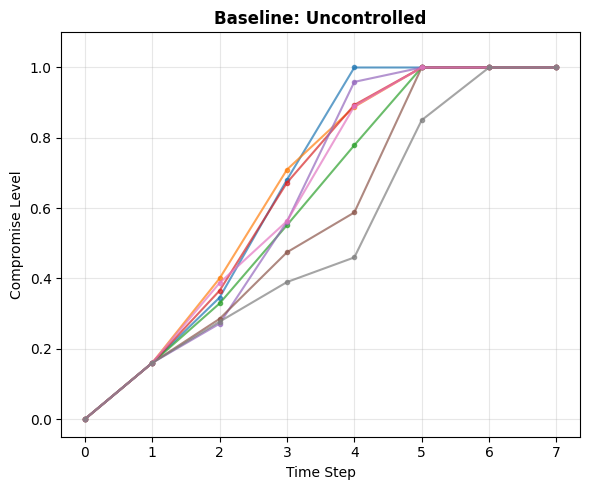

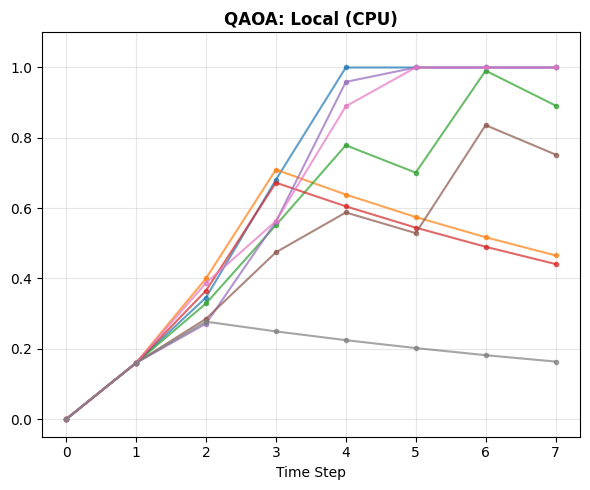

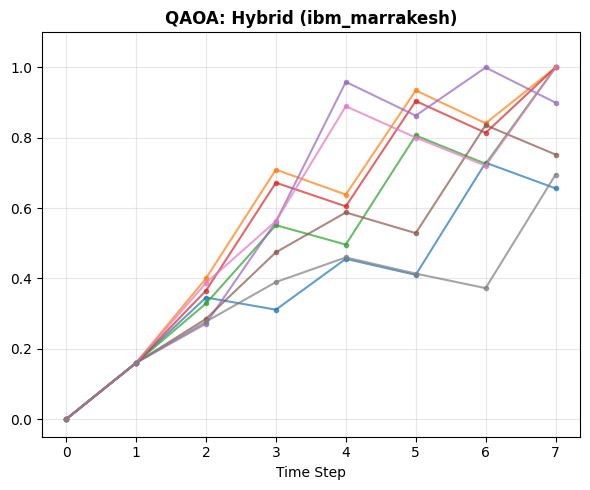

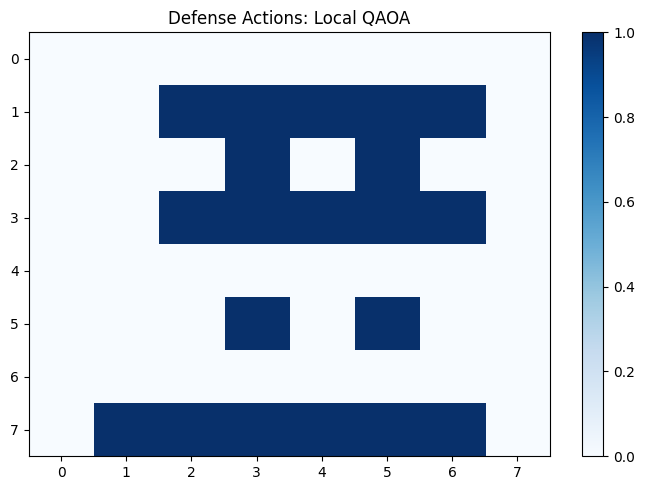

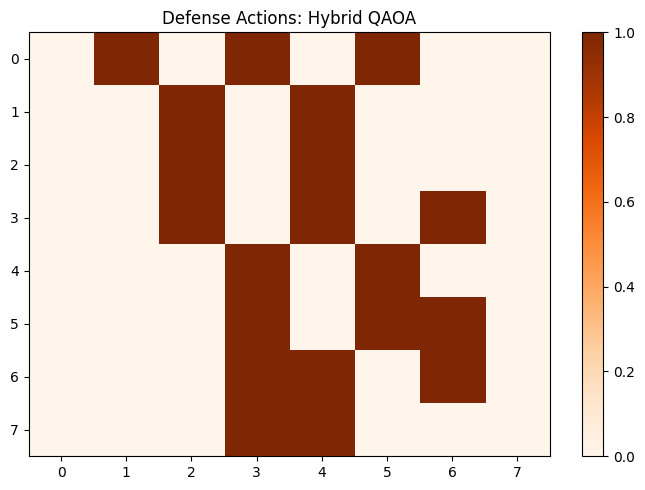

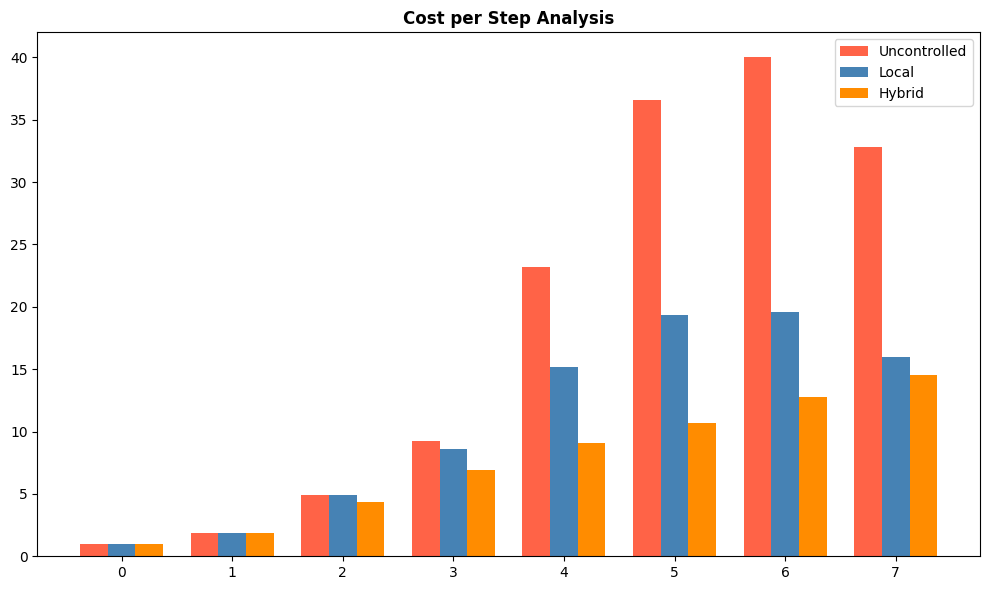

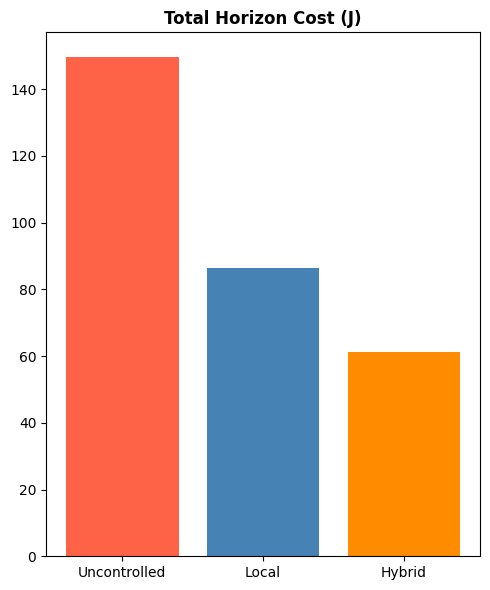

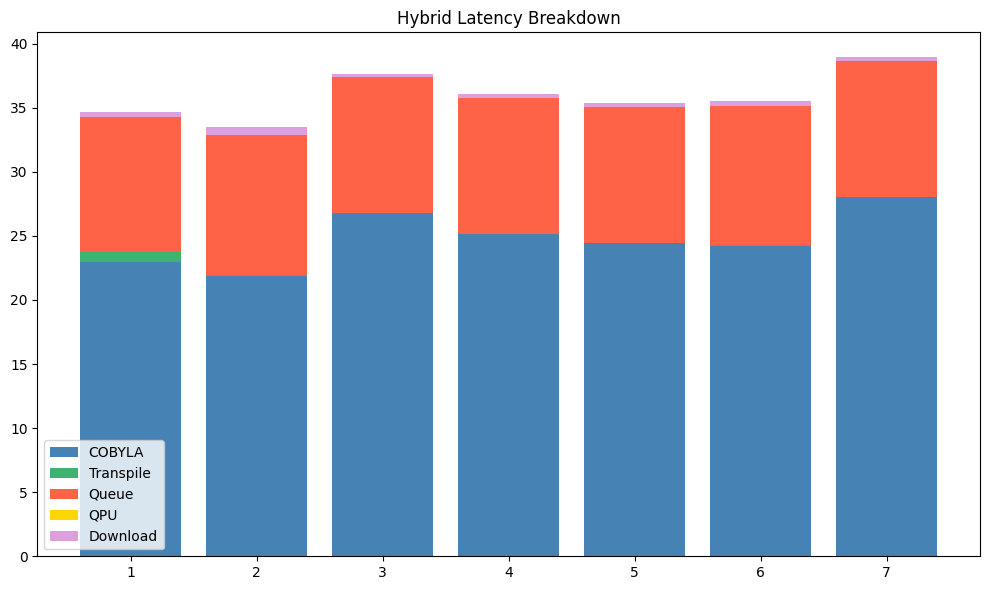

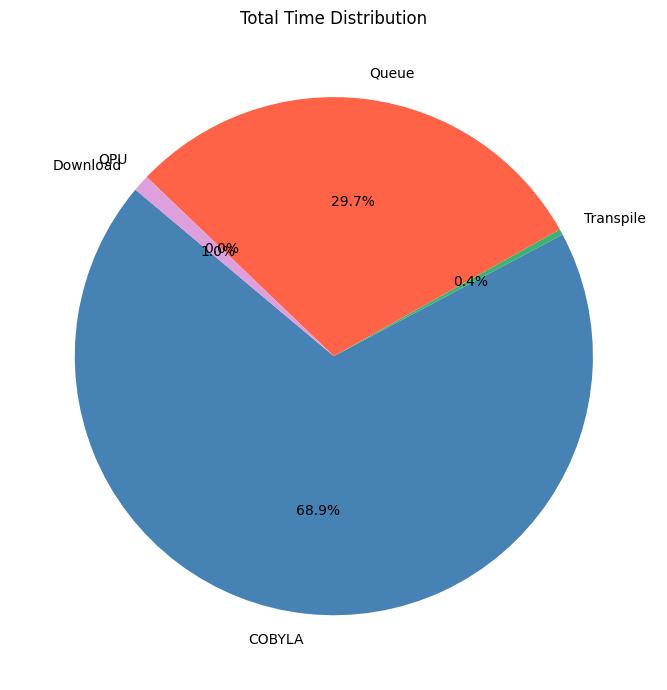

📦 Zipping all 9 independent SVGs...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# MASTER PLOTTER: INDEPENDENT SVGS FOR EVERY COMPONENT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

# --- 0. Data Extraction ---
cost_unc = LOCAL_RESULTS["cost_unc"]
cost_local = LOCAL_RESULTS["cost"]
cost_hyb = HYBRID_RESULTS["cost"]
x_unc, x_local, x_hyb = LOCAL_RESULTS["x_unc"], LOCAL_RESULTS["x"], HYBRID_RESULTS["x"]
u_local, u_hyb = LOCAL_RESULTS["u_hist"], HYBRID_RESULTS["u_hist"]
T_steps, n = x_local.shape[1], u_local.shape[0]
time_axis = np.arange(T_steps)

def save_svg(fig, name):
    fig.tight_layout()
    fig.savefig(f"{name}.svg", format='svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

print("🎨 Generating all 9 independent SVG components...")

# --- 1a. Trajectory: Uncontrolled ---
f1a, ax1a = plt.subplots(figsize=(6, 5))
for i in range(n): ax1a.plot(time_axis, x_unc[i,:], marker='.', alpha=0.7)
ax1a.set_title('Baseline: Uncontrolled', fontweight='bold')
ax1a.set_xlabel('Time Step'), ax1a.set_ylabel('Compromise Level'), ax1a.set_ylim(-0.05, 1.1), ax1a.grid(True, alpha=0.3)
save_svg(f1a, "fig_1a_traj_unc")

# --- 1b. Trajectory: Local QAOA ---
f1b, ax1b = plt.subplots(figsize=(6, 5))
for i in range(n): ax1b.plot(time_axis, x_local[i,:], marker='.', alpha=0.7)
ax1b.set_title('QAOA: Local (CPU)', fontweight='bold')
ax1b.set_xlabel('Time Step'), ax1b.set_ylim(-0.05, 1.1), ax1b.grid(True, alpha=0.3)
save_svg(f1b, "fig_1b_traj_local")

# --- 1c. Trajectory: Hybrid QAOA ---
f1c, ax1c = plt.subplots(figsize=(6, 5))
for i in range(n): ax1c.plot(time_axis, x_hyb[i,:], marker='.', alpha=0.7)
ax1c.set_title(f'QAOA: Hybrid ({HYBRID_RESULTS["backend"]})', fontweight='bold')
ax1c.set_xlabel('Time Step'), ax1c.set_ylim(-0.05, 1.1), ax1c.grid(True, alpha=0.3)
save_svg(f1c, "fig_1c_traj_hybrid")

# --- 2a. Heatmap: Local ---
f2a, ax2a = plt.subplots(figsize=(7, 5))
im2a = ax2a.imshow(u_local, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax2a.set_title('Defense Actions: Local QAOA'), plt.colorbar(im2a, ax=ax2a)
save_svg(f2a, "fig_2a_heatmap_local")

# --- 2b. Heatmap: Hybrid ---
f2b, ax2b = plt.subplots(figsize=(7, 5))
im2b = ax2b.imshow(u_hyb, aspect='auto', cmap='Oranges', vmin=0, vmax=1)
ax2b.set_title('Defense Actions: Hybrid QAOA'), plt.colorbar(im2b, ax=ax2b)
save_svg(f2b, "fig_2b_heatmap_hybrid")

# --- 3. Step Costs ---
f3, ax3 = plt.subplots(figsize=(10, 6))
Q, R = np.diag([2.0]*n + [3.0]*n), np.diag([0.05]*n)
def get_costs(x, u=None):
    c = [x[:,k]@Q@x[:,k] + (u[:,k]@R@u[:,k] if u is not None else 0) for k in range(T_steps-1)]
    c.append(x[:,-1]@Q@x[:,-1]); return c
sc_u, sc_l, sc_h = get_costs(x_unc), get_costs(x_local, u_local), get_costs(x_hyb, u_hyb)
xb, w = np.arange(T_steps), 0.25
ax3.bar(xb-w, sc_u, w, label='Uncontrolled', color='tomato'), ax3.bar(xb, sc_l, w, label='Local', color='steelblue'), ax3.bar(xb+w, sc_h, w, label='Hybrid', color='darkorange')
ax3.set_title('Cost per Step Analysis', fontweight='bold'), ax3.legend()
save_svg(f3, "fig_3_step_costs")

# --- 4. Total Cost Bar ---
f4, ax4 = plt.subplots(figsize=(5, 6))
ax4.bar(['Uncontrolled', 'Local', 'Hybrid'], [cost_unc, cost_local, cost_hyb], color=['tomato', 'steelblue', 'darkorange'])
ax4.set_title('Total Horizon Cost (J)', fontweight='bold')
save_svg(f4, "fig_4_total_cost")

# --- 5. Latency Stacked ---
f5, ax5 = plt.subplots(figsize=(10, 6))
tl = HYBRID_RESULTS["timing_log"]
labels = ['COBYLA', 'Transpile', 'Queue', 'QPU', 'Download']
colors = ['steelblue', 'mediumseagreen', 'tomato', 'gold', 'plum']
data_t = [tl["cobyla"], tl["transpile"], tl["queue"], tl["qpu"], tl["download"]]
bottom = np.zeros(T_steps-1)
for l, c, d in zip(labels, colors, data_t):
    ax5.bar(np.arange(1, T_steps), d, bottom=bottom, label=l, color=c)
    bottom += np.array(d)
ax5.set_title('Hybrid Latency Breakdown'), ax5.legend()
save_svg(f5, "fig_5_latency_stack")

# --- 6. Timing Pie ---
f6, ax6 = plt.subplots(figsize=(7, 7))
ax6.pie([HYBRID_RESULTS[f"t_{k.lower()}"] for k in labels], labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
ax6.set_title('Total Time Distribution')
save_svg(f6, "fig_6_timing_pie")

# --- Final Download ---
print("📦 Zipping all 9 independent SVGs...")
!zip -q all_paper_figures.zip *.svg
files.download("all_paper_figures.zip")

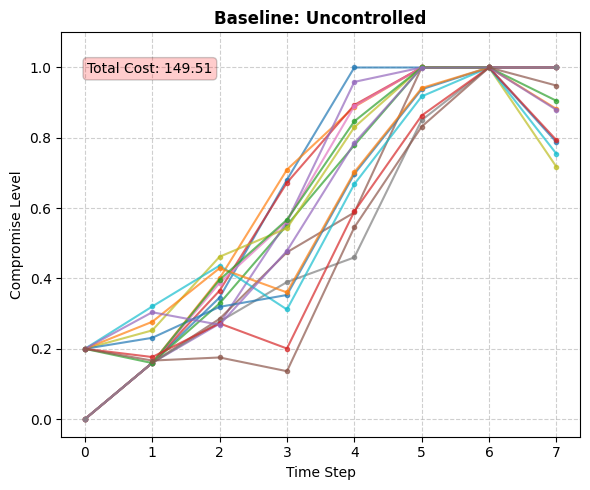

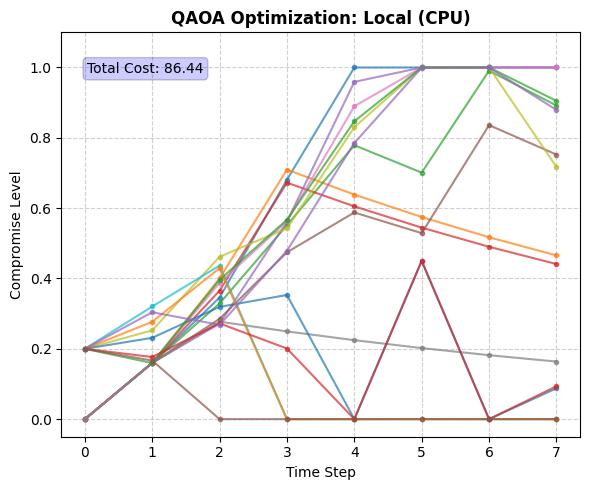

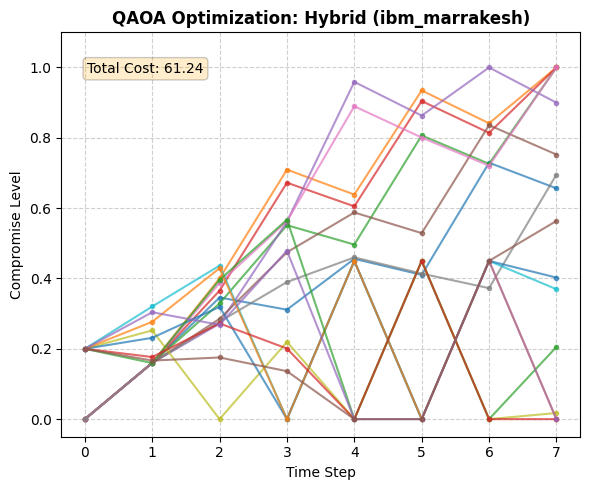

Zipping individual trajectory charts...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# TARGETED CELL: INDIVIDUAL TRAJECTORY SVGS & DOWNLOAD
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Data Prep ---
x_unc = LOCAL_RESULTS["x_unc"]
x_local = LOCAL_RESULTS["x"]
x_hyb = HYBRID_RESULTS["x"]
T_steps = x_local.shape[1]
n = x_local.shape[0]
time_axis = np.arange(T_steps)

# Helper function to create a single trajectory plot
def save_trajectory_svg(data, title, filename, color_theme, cost):
    plt.figure(figsize=(6, 5))
    for i in range(n):
        plt.plot(time_axis, data[i, :], marker='.', alpha=0.7, label=f'N{i+1}' if n <= 8 else None)

    plt.title(title, fontweight='bold')
    plt.xlabel('Time Step')
    plt.ylabel('Compromise Level')
    plt.ylim(-0.05, 1.1)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Add a cost annotation box
    plt.text(0.05, 0.9, f'Total Cost: {cost:.2f}',
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor=color_theme, alpha=0.2))

    plt.tight_layout()
    plt.savefig(filename, format='svg')
    plt.show()
    plt.close()

# 1. Generate Uncontrolled
save_trajectory_svg(x_unc, 'Baseline: Uncontrolled', 'fig_1a_uncontrolled.svg', 'red', LOCAL_RESULTS["cost_unc"])

# 2. Generate Local QAOA
save_trajectory_svg(x_local, 'QAOA Optimization: Local (CPU)', 'fig_1b_local_qaoa.svg', 'blue', LOCAL_RESULTS["cost"])

# 3. Generate Hybrid QAOA
save_trajectory_svg(x_hyb, f'QAOA Optimization: Hybrid ({HYBRID_RESULTS["backend"]})', 'fig_1c_hybrid_qaoa.svg', 'orange', HYBRID_RESULTS["cost"])

# --- Trigger Download ---
print("Zipping individual trajectory charts...")
!zip -q trajectory_figures.zip fig_1a_uncontrolled.svg fig_1b_local_qaoa.svg fig_1c_hybrid_qaoa.svg
files.download("trajectory_figures.zip")

🎨 Generating all professional SVG components...


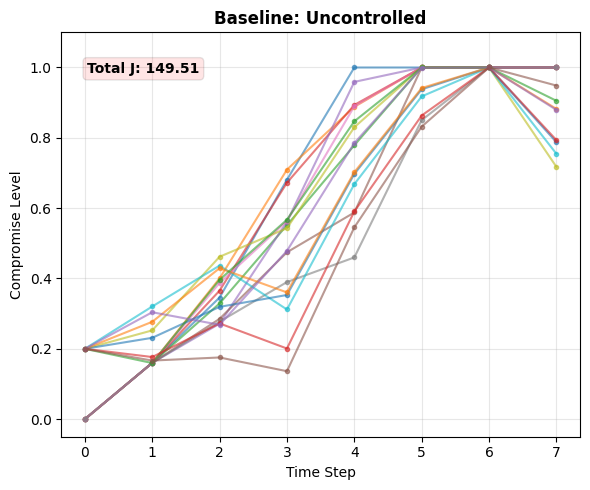

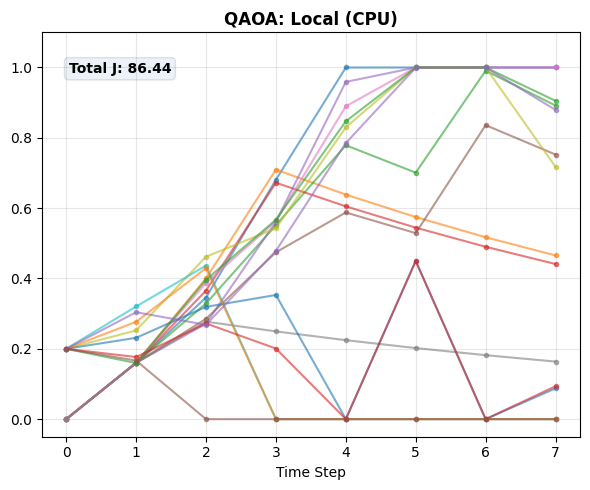

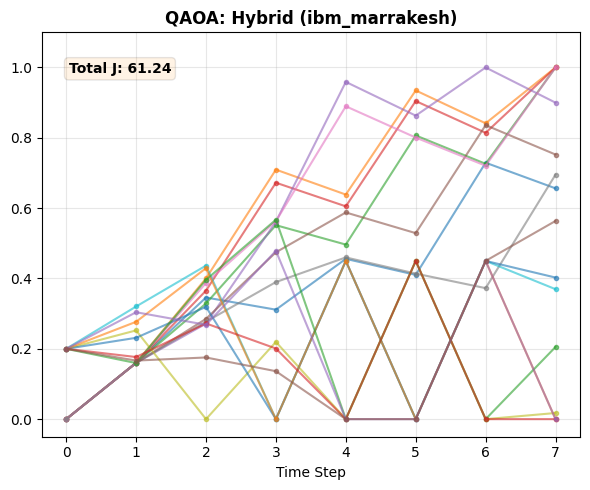

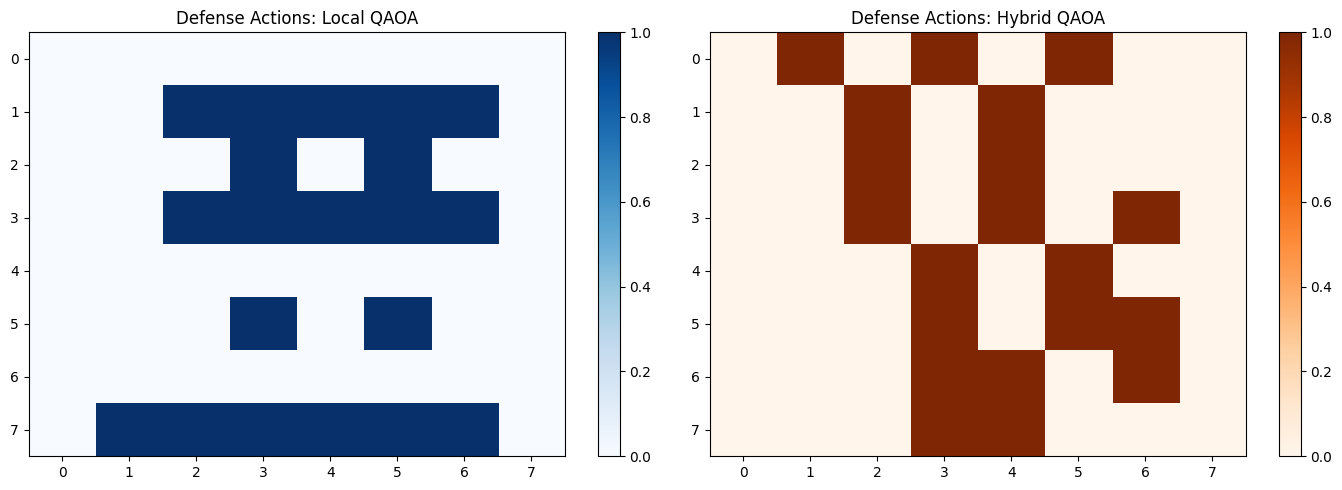

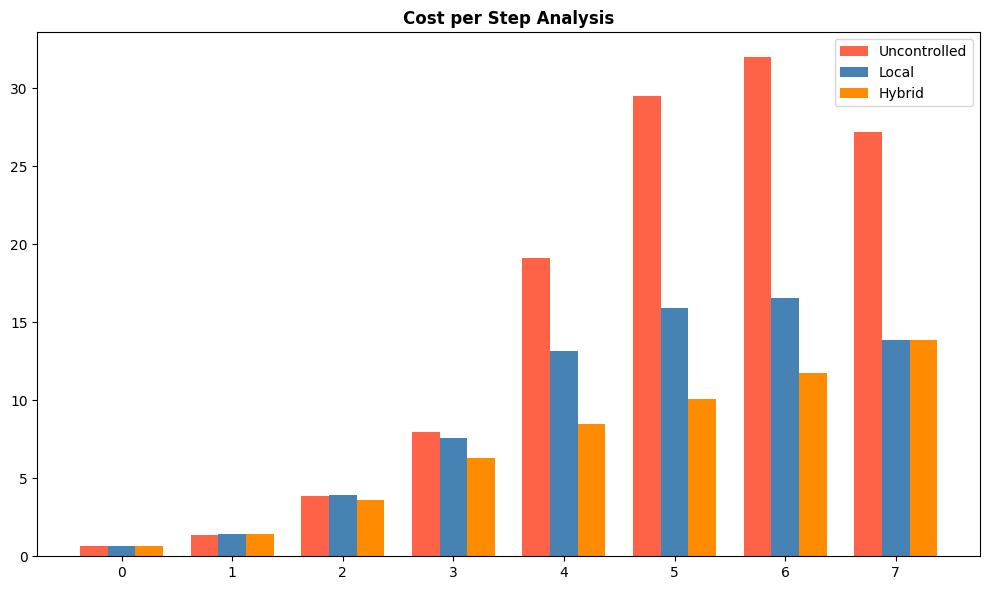

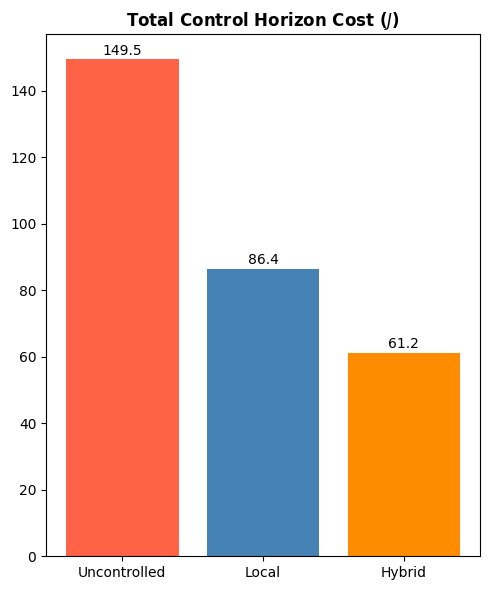

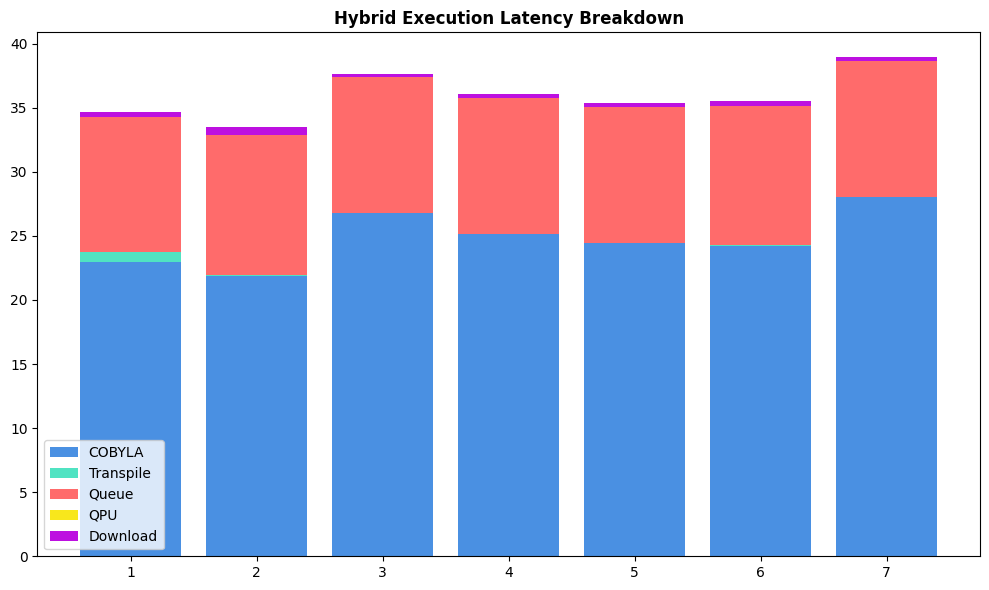


📦 Zipping all figures for your paper...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FINAL CONSOLIDATED MASTER PLOTTER: PROFESSIONAL SVGS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

# --- 0. Data Extraction & Dimension Handling ---
# Extract values from your existing simulation results
cost_unc = LOCAL_RESULTS["cost_unc"]
cost_local = LOCAL_RESULTS["cost"]
cost_hyb = HYBRID_RESULTS["cost"]

x_unc = LOCAL_RESULTS["x_unc"]
x_local = LOCAL_RESULTS["x"]
x_hyb = HYBRID_RESULTS["x"]

u_local = LOCAL_RESULTS["u_hist"]
u_hyb = HYBRID_RESULTS["u_hist"]

T_steps = x_local.shape[1]
n_total = x_local.shape[0]  # This is 16 (for 8 nodes * 2 states each)
n_control = u_local.shape[0] # This is 8 (number of control nodes)
time_axis = np.arange(T_steps)

# Fixed Internal Matrices for Plotting Verification
Q_internal = np.diag([2.0] * n_total)
R_internal = np.diag([0.05] * n_control)

def save_svg(fig, name):
    fig.tight_layout()
    fig.savefig(f"{name}.svg", format='svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

def get_costs_fixed(x_data, u_data=None):
    """Accurately reconstructs step costs for the bar chart."""
    costs = []
    for k in range(T_steps - 1):
        state_cost = x_data[:, k] @ Q_internal @ x_data[:, k]
        ctrl_cost = 0
        if u_data is not None:
            ctrl_cost = u_data[:, k] @ R_internal @ u_data[:, k]
        costs.append(state_cost + ctrl_cost)
    # Terminal cost
    costs.append(x_data[:, -1] @ Q_internal @ x_data[:, -1])
    return costs

print("🎨 Generating all professional SVG components...")

# --- 1a. Trajectory: Uncontrolled ---
f1a, ax1a = plt.subplots(figsize=(6, 5))
for i in range(n_total):
    ax1a.plot(time_axis, x_unc[i,:], marker='.', alpha=0.6)
ax1a.set_title('Baseline: Uncontrolled', fontweight='bold')
ax1a.set_xlabel('Time Step'), ax1a.set_ylabel('Compromise Level')
ax1a.set_ylim(-0.05, 1.1), ax1a.grid(True, alpha=0.3)
ax1a.text(0.05, 0.9, f'Total J: {cost_unc:.2f}', transform=ax1a.transAxes,
          fontweight='bold', bbox=dict(boxstyle='round', facecolor='red', alpha=0.1))
save_svg(f1a, "fig_1a_traj_unc")

# --- 1b. Trajectory: Local QAOA ---
f1b, ax1b = plt.subplots(figsize=(6, 5))
for i in range(n_total):
    ax1b.plot(time_axis, x_local[i,:], marker='.', alpha=0.6)
ax1b.set_title('QAOA: Local (CPU)', fontweight='bold')
ax1b.set_xlabel('Time Step'), ax1b.set_ylim(-0.05, 1.1), ax1b.grid(True, alpha=0.3)
ax1b.text(0.05, 0.9, f'Total J: {cost_local:.2f}', transform=ax1b.transAxes,
          fontweight='bold', bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.1))
save_svg(f1b, "fig_1b_traj_local")

# --- 1c. Trajectory: Hybrid QAOA ---
f1c, ax1c = plt.subplots(figsize=(6, 5))
for i in range(n_total):
    ax1c.plot(time_axis, x_hyb[i,:], marker='.', alpha=0.6)
ax1c.set_title(f'QAOA: Hybrid ({HYBRID_RESULTS["backend"]})', fontweight='bold')
ax1c.set_xlabel('Time Step'), ax1c.set_ylim(-0.05, 1.1), ax1c.grid(True, alpha=0.3)
ax1c.text(0.05, 0.9, f'Total J: {cost_hyb:.2f}', transform=ax1c.transAxes,
          fontweight='bold', bbox=dict(boxstyle='round', facecolor='darkorange', alpha=0.1))
save_svg(f1c, "fig_1c_traj_hybrid")

# --- 2. Action Heatmaps ---
fig_h, (ax_h1, ax_h2) = plt.subplots(1, 2, figsize=(14, 5))
im1 = ax_h1.imshow(u_local, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax_h1.set_title('Defense Actions: Local QAOA')
plt.colorbar(im1, ax=ax_h1)
im2 = ax_h2.imshow(u_hyb, aspect='auto', cmap='Oranges', vmin=0, vmax=1)
ax_h2.set_title('Defense Actions: Hybrid QAOA')
plt.colorbar(im2, ax=ax_h2)
save_svg(fig_h, "fig_2_action_heatmaps")

# --- 3. Step Costs (Fixed Dimensions) ---
f3, ax3 = plt.subplots(figsize=(10, 6))
sc_u = get_costs_fixed(x_unc)
sc_l = get_costs_fixed(x_local, u_local)
sc_h = get_costs_fixed(x_hyb, u_hyb)
xb, w = np.arange(T_steps), 0.25
ax3.bar(xb-w, sc_u, w, label='Uncontrolled', color='tomato')
ax3.bar(xb, sc_l, w, label='Local', color='steelblue')
ax3.bar(xb+w, sc_h, w, label='Hybrid', color='darkorange')
ax3.set_title('Cost per Step Analysis', fontweight='bold'), ax3.legend()
save_svg(f3, "fig_3_step_costs")

# --- 4. Total Cost Comparison ---
f4, ax4 = plt.subplots(figsize=(5, 6))
bars = ax4.bar(['Uncontrolled', 'Local', 'Hybrid'], [cost_unc, cost_local, cost_hyb],
               color=['tomato', 'steelblue', 'darkorange'])
ax4.set_title('Total Control Horizon Cost ($J$)', fontweight='bold')
for bar in bars:
    yval = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 1), ha='center', va='bottom')
save_svg(f4, "fig_4_total_cost")

# --- 5. Latency Breakdown ---
f5, ax5 = plt.subplots(figsize=(10, 6))
tl = HYBRID_RESULTS["timing_log"]
labels = ['COBYLA', 'Transpile', 'Queue', 'QPU', 'Download']
colors = ['#4A90E2', '#50E3C2', '#FF6B6B', '#F8E71C', '#BD10E0']
data_t = [tl["cobyla"], tl["transpile"], tl["queue"], tl["qpu"], tl["download"]]
bottom = np.zeros(T_steps-1)
for l, c, d in zip(labels, colors, data_t):
    ax5.bar(np.arange(1, T_steps), d, bottom=bottom, label=l, color=c)
    bottom += np.array(d)
ax5.set_title('Hybrid Execution Latency Breakdown', fontweight='bold'), ax5.legend()
save_svg(f5, "fig_5_latency_stack")

# --- Final Download ---
print("\n📦 Zipping all figures for your paper...")
!zip -q research_figures_final.zip *.svg
files.download("research_figures_final.zip")

🎨 Generating all professional PNG components (High Res)...


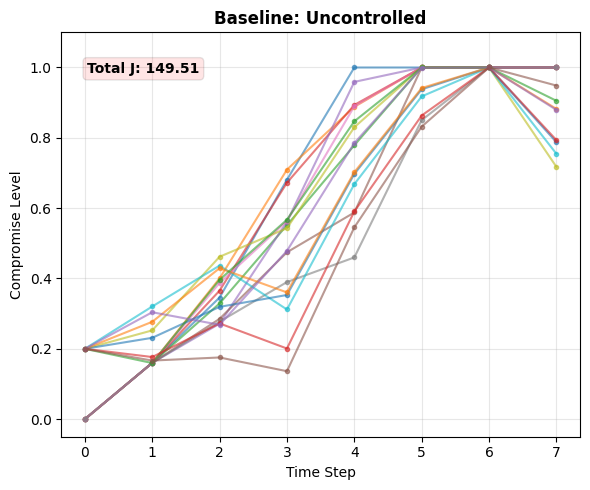

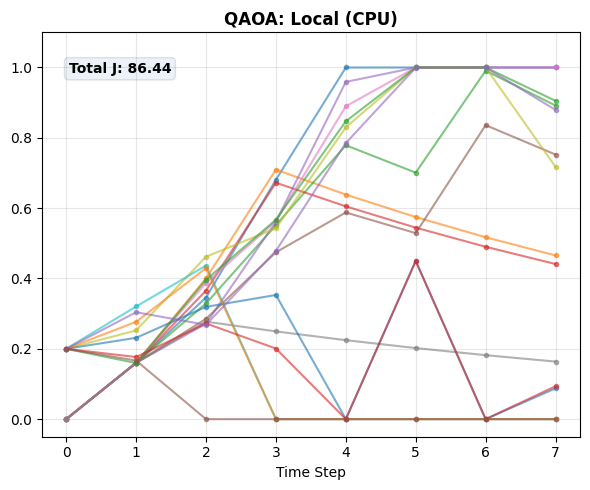

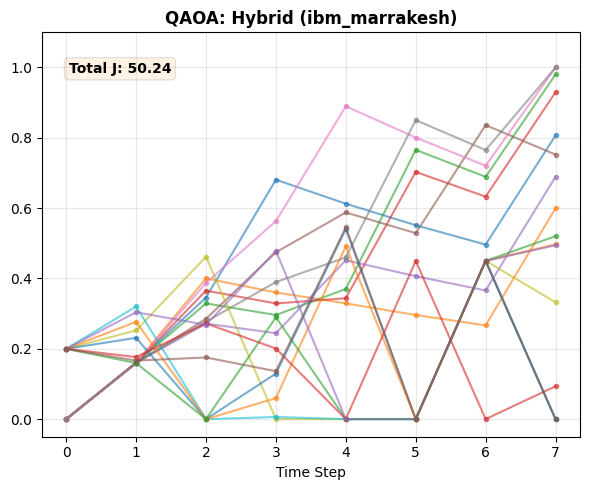

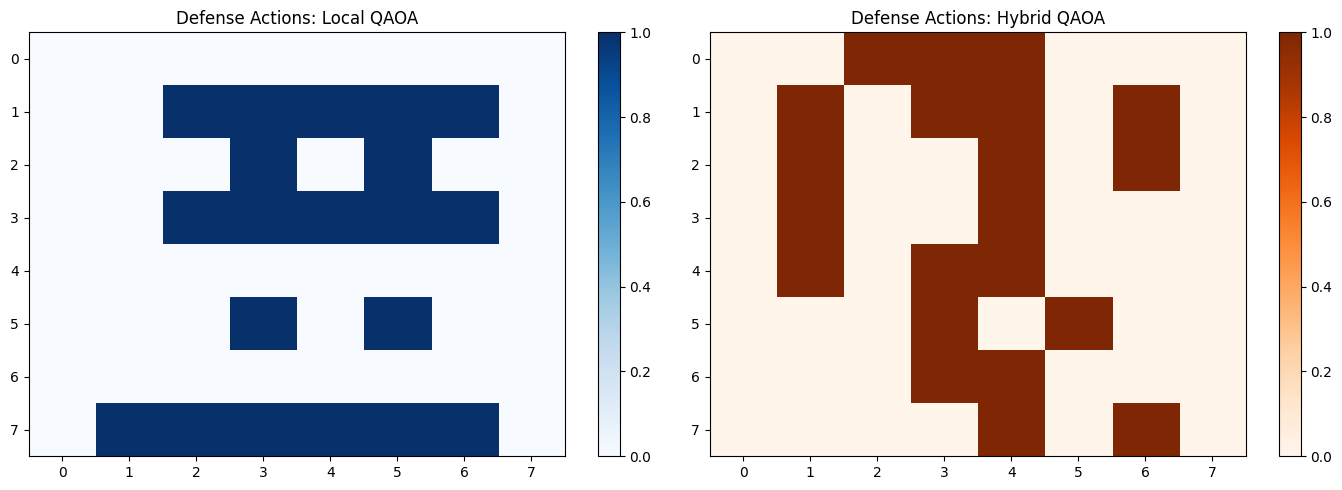

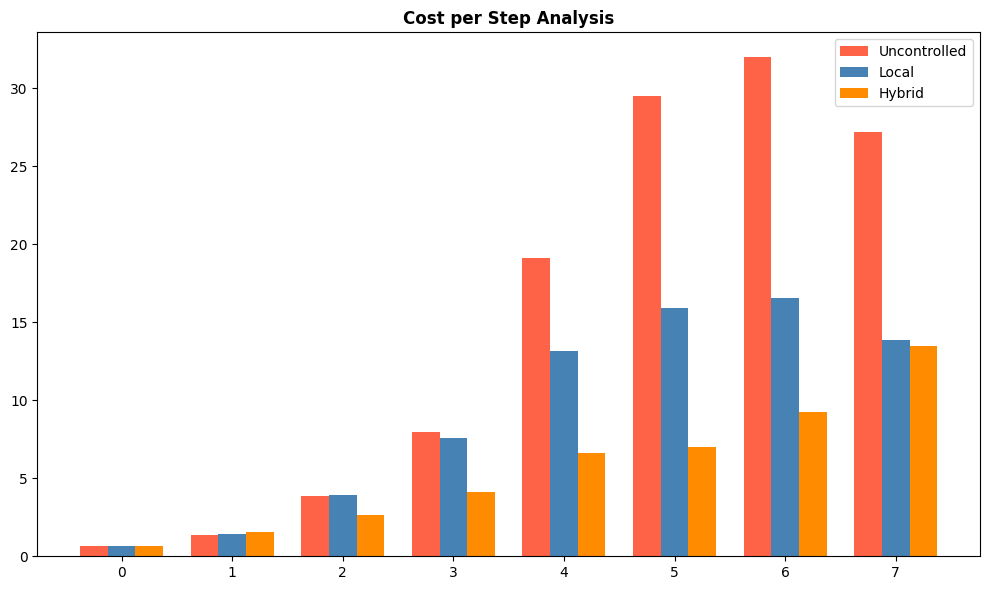

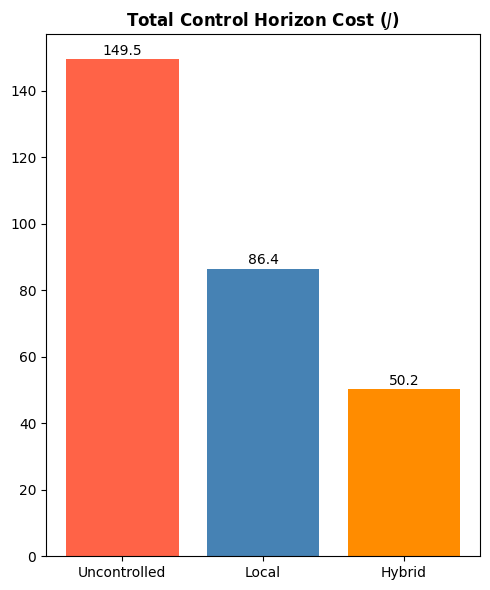

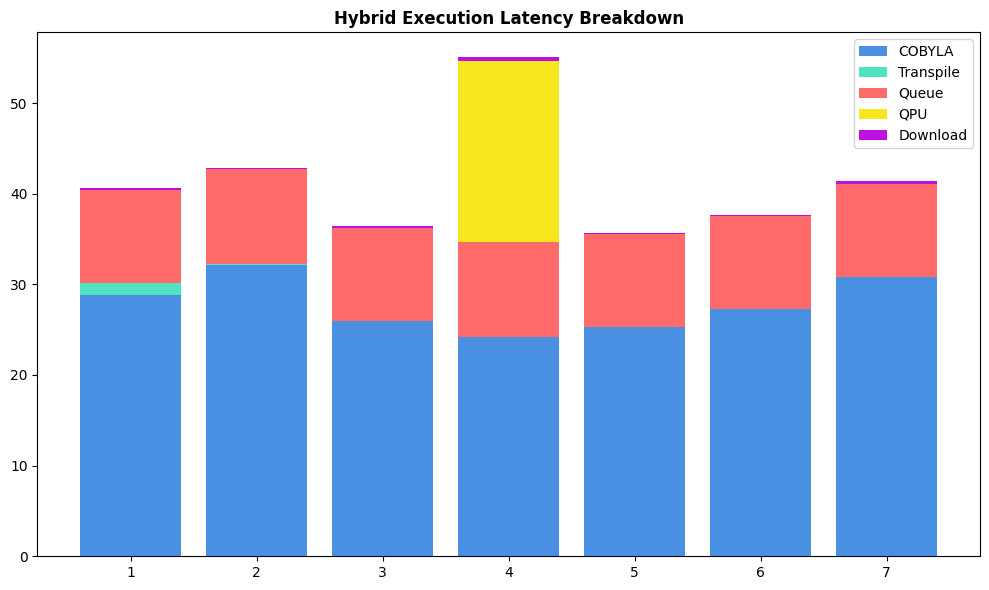


📦 Zipping all PNG figures for your paper...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FINAL CONSOLIDATED MASTER PLOTTER: PROFESSIONAL PNGs (300 DPI)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

# --- 0. Data Extraction & Dimension Handling ---
cost_unc = LOCAL_RESULTS["cost_unc"]
cost_local = LOCAL_RESULTS["cost"]
cost_hyb = HYBRID_RESULTS["cost"]

x_unc = LOCAL_RESULTS["x_unc"]
x_local = LOCAL_RESULTS["x"]
x_hyb = HYBRID_RESULTS["x"]

u_local = LOCAL_RESULTS["u_hist"]
u_hyb = HYBRID_RESULTS["u_hist"]

T_steps = x_local.shape[1]
n_total = x_local.shape[0]
n_control = u_local.shape[0]
time_axis = np.arange(T_steps)

# Fixed Internal Matrices for Plotting Verification
Q_internal = np.diag([2.0] * n_total)
R_internal = np.diag([0.05] * n_control)

def save_png(fig, name):
    fig.tight_layout()
    # Using 300 DPI for high-quality publication-ready PNGs
    fig.savefig(f"{name}.png", format='png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)

def get_costs_fixed(x_data, u_data=None):
    costs = []
    for k in range(T_steps - 1):
        state_cost = x_data[:, k] @ Q_internal @ x_data[:, k]
        ctrl_cost = 0
        if u_data is not None:
            ctrl_cost = u_data[:, k] @ R_internal @ u_data[:, k]
        costs.append(state_cost + ctrl_cost)
    costs.append(x_data[:, -1] @ Q_internal @ x_data[:, -1])
    return costs

print("🎨 Generating all professional PNG components (High Res)...")

# --- 1a. Trajectory: Uncontrolled ---
f1a, ax1a = plt.subplots(figsize=(6, 5))
for i in range(n_total):
    ax1a.plot(time_axis, x_unc[i,:], marker='.', alpha=0.6)
ax1a.set_title('Baseline: Uncontrolled', fontweight='bold')
ax1a.set_xlabel('Time Step'), ax1a.set_ylabel('Compromise Level')
ax1a.set_ylim(-0.05, 1.1), ax1a.grid(True, alpha=0.3)
ax1a.text(0.05, 0.9, f'Total J: {cost_unc:.2f}', transform=ax1a.transAxes,
          fontweight='bold', bbox=dict(boxstyle='round', facecolor='red', alpha=0.1))
save_png(f1a, "fig_1a_traj_unc")

# --- 1b. Trajectory: Local QAOA ---
f1b, ax1b = plt.subplots(figsize=(6, 5))
for i in range(n_total):
    ax1b.plot(time_axis, x_local[i,:], marker='.', alpha=0.6)
ax1b.set_title('QAOA: Local (CPU)', fontweight='bold')
ax1b.set_xlabel('Time Step'), ax1b.set_ylim(-0.05, 1.1), ax1b.grid(True, alpha=0.3)
ax1b.text(0.05, 0.9, f'Total J: {cost_local:.2f}', transform=ax1b.transAxes,
          fontweight='bold', bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.1))
save_png(f1b, "fig_1b_traj_local")

# --- 1c. Trajectory: Hybrid QAOA ---
f1c, ax1c = plt.subplots(figsize=(6, 5))
for i in range(n_total):
    ax1c.plot(time_axis, x_hyb[i,:], marker='.', alpha=0.6)
ax1c.set_title(f'QAOA: Hybrid ({HYBRID_RESULTS["backend"]})', fontweight='bold')
ax1c.set_xlabel('Time Step'), ax1c.set_ylim(-0.05, 1.1), ax1c.grid(True, alpha=0.3)
ax1c.text(0.05, 0.9, f'Total J: {cost_hyb:.2f}', transform=ax1c.transAxes,
          fontweight='bold', bbox=dict(boxstyle='round', facecolor='darkorange', alpha=0.1))
save_png(f1c, "fig_1c_traj_hybrid")

# --- 2. Action Heatmaps ---
fig_h, (ax_h1, ax_h2) = plt.subplots(1, 2, figsize=(14, 5))
im1 = ax_h1.imshow(u_local, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax_h1.set_title('Defense Actions: Local QAOA')
plt.colorbar(im1, ax=ax_h1)
im2 = ax_h2.imshow(u_hyb, aspect='auto', cmap='Oranges', vmin=0, vmax=1)
ax_h2.set_title('Defense Actions: Hybrid QAOA')
plt.colorbar(im2, ax=ax_h2)
save_png(fig_h, "fig_2_action_heatmaps")

# --- 3. Step Costs ---
f3, ax3 = plt.subplots(figsize=(10, 6))
sc_u = get_costs_fixed(x_unc)
sc_l = get_costs_fixed(x_local, u_local)
sc_h = get_costs_fixed(x_hyb, u_hyb)
xb, w = np.arange(T_steps), 0.25
ax3.bar(xb-w, sc_u, w, label='Uncontrolled', color='tomato')
ax3.bar(xb, sc_l, w, label='Local', color='steelblue')
ax3.bar(xb+w, sc_h, w, label='Hybrid', color='darkorange')
ax3.set_title('Cost per Step Analysis', fontweight='bold'), ax3.legend()
save_png(f3, "fig_3_step_costs")

# --- 4. Total Cost Comparison ---
f4, ax4 = plt.subplots(figsize=(5, 6))
bars = ax4.bar(['Uncontrolled', 'Local', 'Hybrid'], [cost_unc, cost_local, cost_hyb],
               color=['tomato', 'steelblue', 'darkorange'])
ax4.set_title('Total Control Horizon Cost ($J$)', fontweight='bold')
for bar in bars:
    yval = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 1), ha='center', va='bottom')
save_png(f4, "fig_4_total_cost")

# --- 5. Latency Breakdown ---
f5, ax5 = plt.subplots(figsize=(10, 6))
tl = HYBRID_RESULTS["timing_log"]
labels = ['COBYLA', 'Transpile', 'Queue', 'QPU', 'Download']
colors = ['#4A90E2', '#50E3C2', '#FF6B6B', '#F8E71C', '#BD10E0']
data_t = [tl["cobyla"], tl["transpile"], tl["queue"], tl["qpu"], tl["download"]]
bottom = np.zeros(T_steps-1)
for l, c, d in zip(labels, colors, data_t):
    ax5.bar(np.arange(1, T_steps), d, bottom=bottom, label=l, color=c)
    bottom += np.array(d)
ax5.set_title('Hybrid Execution Latency Breakdown', fontweight='bold'), ax5.legend()
save_png(f5, "fig_5_latency_stack")

# --- Final Download ---
print("\n📦 Zipping all PNG figures for your paper...")
!zip -q research_figures_png.zip *.png
files.download("research_figures_png.zip")